In [4]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from image_processing.gaze_dep_models import save_pixelwise_luminance, save_OF


In [48]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    sq_side = 250
    downsampled_sq_size = 50
    sensors_group = 'par'
    model_name = "pixelwise_luminance"
    time_points = 100
    pseudotrials_n = 500
    max_lag=100
cfg = Cfg()

In [49]:
neu_rep1, labels1 = load_meg_data(paths, cfg.sub_num, cfg.run, cfg.sensors_group, cfg.neu_fs)
gaze_rep1, _ = load_eyetracking_data(paths, cfg.sub_num, cfg.run, cfg.gaze_fs, xy=True)

neu_rep2, labels2 = load_meg_data(paths, cfg.sub_num, cfg.run+3, cfg.sensors_group, cfg.neu_fs)

In [50]:
gaze_rep1.resample(cfg.neu_fs)

In [51]:
min_len = min(len(gaze_rep1), len(neu_rep1))
X = TimeSeries(gaze_rep1.get_array()[:,:min_len,np.newaxis], neu_rep1.get_fs())
Y = TimeSeries(neu_rep1.get_array()[:,:min_len,np.newaxis], neu_rep1.get_fs())

In [52]:
model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="r2")
# X.z_score_feats()
Y.z_score_feats()
s = model.crossvalidate_general_dyn(X, Y)

In [53]:
x = np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), 10/s.get_fs())
print(x.shape)

(21,)


In [63]:
ticks_labels

array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8])

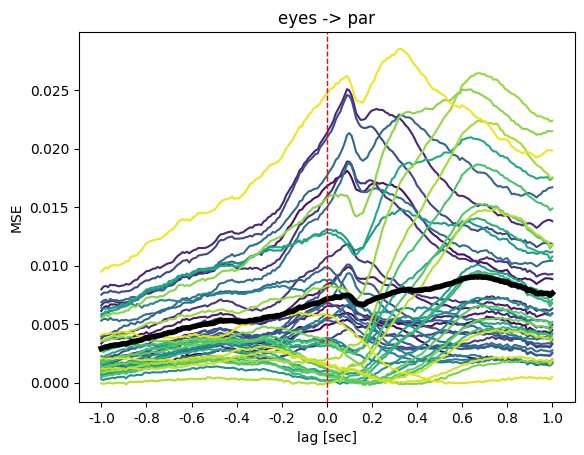

In [67]:
import matplotlib.pyplot as plt
import numpy as np

data = s.get_array()
n_lines = data.shape[0]
tick_step = 20
cmap = plt.get_cmap("viridis")  # choose your cmap
max_lag = cfg.max_lag
fs = s.get_fs()
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / fs, 2)
ticks+= max_lag
for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color, label=labels1[i])

# mean in black (on top)
# ticks = np.arange(-cfg.max_lag-1, cfg.max_lag+1, tick_step) + cfg.max_lag
# ticks_labels = np.round(np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), tick_step/s.get_fs()), 2)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.xticks(ticks, ticks_labels)
plt.axvline(data.shape[1]//2, color="r", linestyle="--", linewidth=1)
plt.title(f"eyes -> {cfg.sensors_group}")
plt.ylabel("MSE")
plt.xlabel("lag [sec]");

# plt.legend(fontsize=6)